# 04 - 次元削減による画像ベクトル可視化

768次元の画像埋め込みベクトルを2D/3Dに次元削減し、カテゴリごとに色分けして可視化する。

## 入力
- `data/images.duckdb` (image_catalog, image_embeddings テーブル)

## 使用する次元削減手法
1. **PCA** - 線形次元削減、高速、ベースライン
2. **t-SNE** - 非線形、局所構造重視
3. **UMAP** - 非線形、大域+局所構造を保持（オプショナル）

## 出力
- 静的な2D/3D散布図（matplotlib）
- インタラクティブな2D/3D散布図（Plotly）

In [2]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Image as IPImage, clear_output
import ipywidgets as widgets

# UMAPはオプショナル（Python 3.13では互換性問題あり）
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("umap-learn がインストールされていません。UMAPセクションはスキップされます。")

umap-learn がインストールされていません。UMAPセクションはスキップされます。


## 設定

In [3]:
# DuckDBファイルのパス
DB_PATH = Path("../data/images.duckdb")

# 再現性のためのランダムシード
RANDOM_STATE = 42

# カテゴリと色のマッピング
CATEGORIES = [
    "EuroPython2025",
    "PyConJP2025",
    "PyConJP2025-PreCampHiroshima",
    "KashiwaVillagePark2026",
    "TokyoNight202505",
    "terada",
]
PALETTE = sns.color_palette("husl", n_colors=len(CATEGORIES))
CATEGORY_COLORS = dict(zip(CATEGORIES, PALETTE))

## データ読み込み

In [4]:
# データベース接続
conn = duckdb.connect(str(DB_PATH), read_only=True)

# 埋め込みとメタデータを結合して取得
query = """
    SELECT 
        e.id,
        e.embedding,
        c.file_name,
        c.category,
        c.file_path
    FROM image_embeddings e
    JOIN image_catalog c ON e.id = c.id
    ORDER BY c.category, c.file_name
"""
results = conn.execute(query).fetchall()

# NumPy配列とDataFrameに変換
embeddings = np.array([r[1] for r in results])
metadata = pd.DataFrame([
    {"id": r[0], "file_name": r[2], "category": r[3], "file_path": r[4]}
    for r in results
])

print(f"埋め込み行列の形状: {embeddings.shape}")
print(f"画像数: {len(metadata)}")
print(f"\nカテゴリ別件数:")
print(metadata["category"].value_counts())

埋め込み行列の形状: (385, 768)
画像数: 385

カテゴリ別件数:
category
EuroPython2025                  129
PyConJP2025                      77
PyConJP2025-PreCampHiroshima     57
KashiwaVillagePark2026           56
TokyoNight202505                 56
terada                           10
Name: count, dtype: int64


## 可視化用ヘルパー関数

In [5]:
def plot_2d_scatter(
    coords: np.ndarray,
    categories: list[str],
    title: str,
    ax: plt.Axes | None = None,
    figsize: tuple[int, int] = (10, 8),
) -> plt.Axes:
    """2D散布図をプロット"""
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    for cat in CATEGORIES:
        mask = np.array(categories) == cat
        if mask.sum() > 0:
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                c=[CATEGORY_COLORS[cat]],
                label=cat,
                alpha=0.7,
                s=50,
            )
    
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    
    return ax


def plot_3d_scatter(
    coords: np.ndarray,
    categories: list[str],
    title: str,
    figsize: tuple[int, int] = (12, 10),
) -> plt.Figure:
    """3D散布図をプロット"""
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    
    for cat in CATEGORIES:
        mask = np.array(categories) == cat
        if mask.sum() > 0:
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                coords[mask, 2],
                c=[CATEGORY_COLORS[cat]],
                label=cat,
                alpha=0.7,
                s=50,
            )
    
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")
    
    return fig

---
## 1. PCA（主成分分析）

線形次元削減手法。分散を最大化する方向に射影する。高速で解釈しやすいが、非線形構造は捉えにくい。

In [6]:
# PCA 2D
print("PCA (2D) を実行中...")
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d_coords = pca_2d.fit_transform(embeddings)

print(f"累積寄与率: {pca_2d.explained_variance_ratio_.sum():.2%}")

PCA (2D) を実行中...
累積寄与率: 24.19%


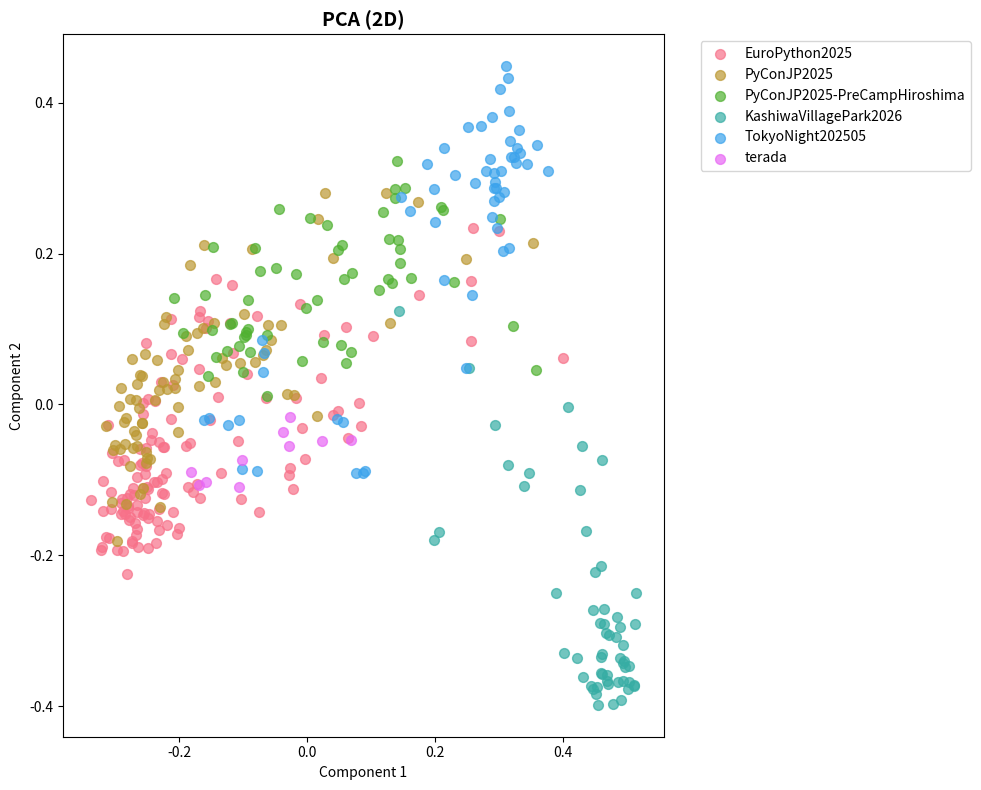

In [7]:
# PCA 2D 可視化
plot_2d_scatter(pca_2d_coords, metadata["category"].tolist(), "PCA (2D)")
plt.tight_layout()
plt.show()

In [8]:
# PCA 3D
print("PCA (3D) を実行中...")
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
pca_3d_coords = pca_3d.fit_transform(embeddings)

print(f"累積寄与率: {pca_3d.explained_variance_ratio_.sum():.2%}")

PCA (3D) を実行中...
累積寄与率: 29.46%


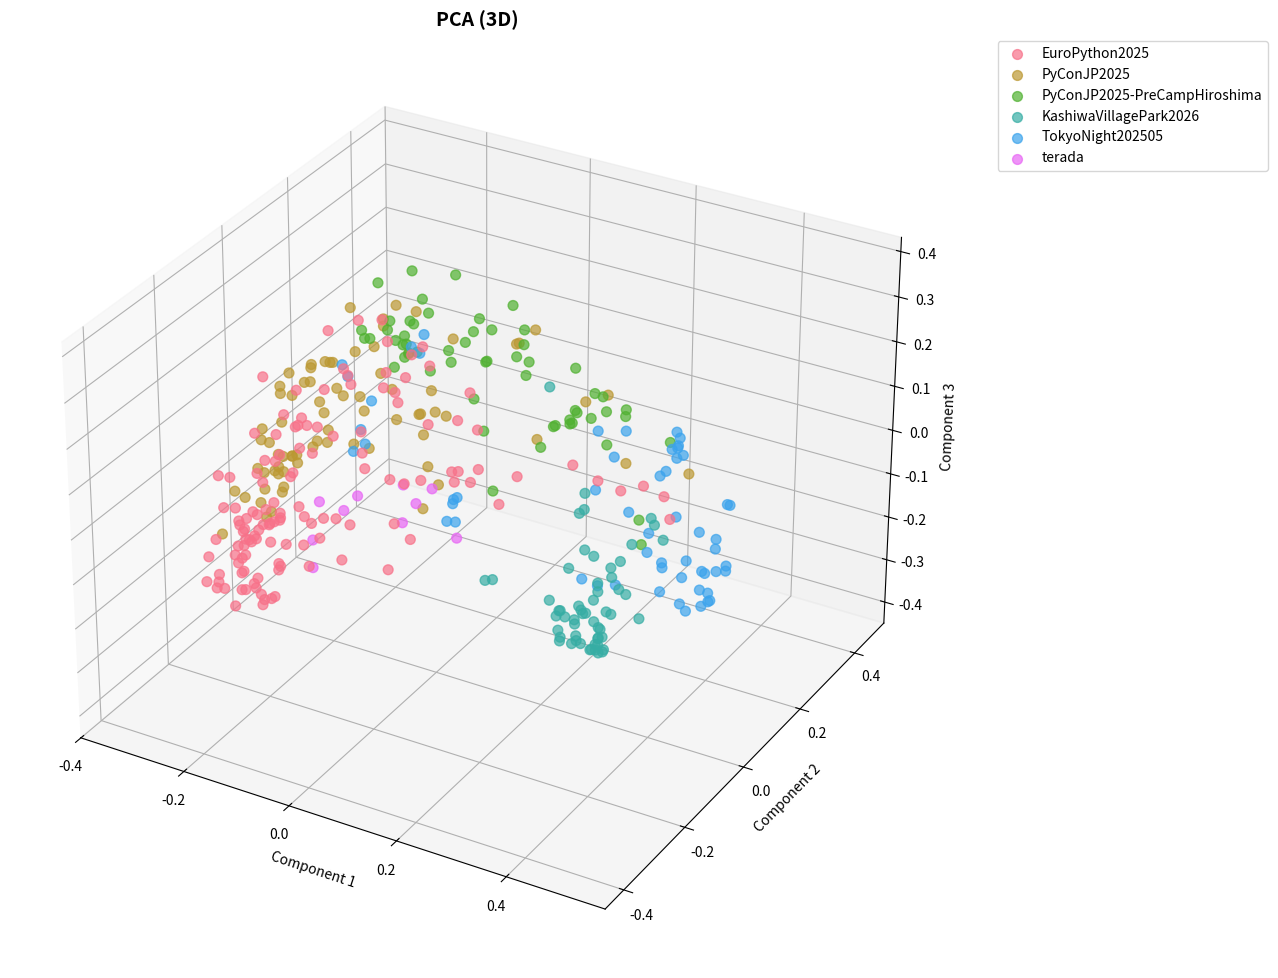

In [9]:
# PCA 3D 可視化
plot_3d_scatter(pca_3d_coords, metadata["category"].tolist(), "PCA (3D)")
plt.tight_layout()
plt.show()

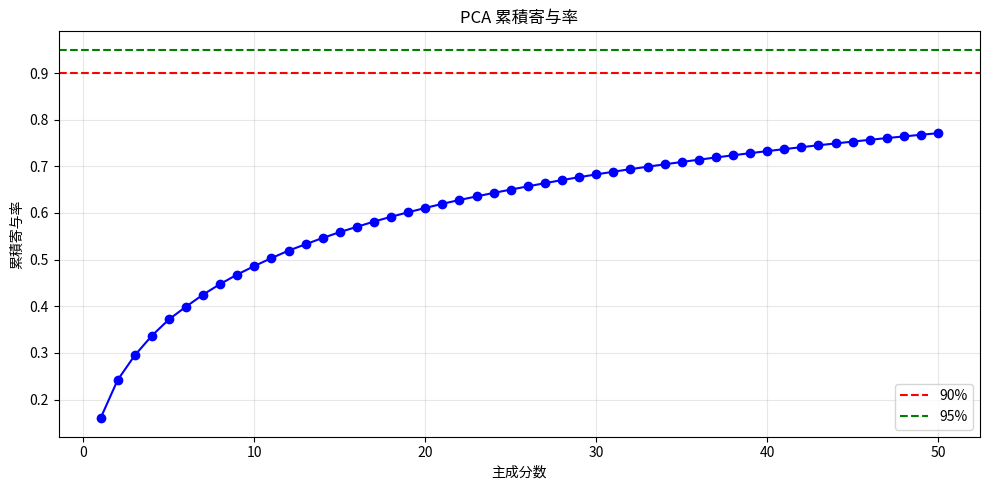

90%寄与率に必要な主成分数: 1
95%寄与率に必要な主成分数: 1


In [10]:
# 累積寄与率プロット
pca_full = PCA(n_components=min(50, embeddings.shape[1]), random_state=RANDOM_STATE)
pca_full.fit(embeddings)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumsum) + 1), cumsum, "bo-")
ax.axhline(y=0.9, color="r", linestyle="--", label="90%")
ax.axhline(y=0.95, color="g", linestyle="--", label="95%")
ax.set_xlabel("主成分数")
ax.set_ylabel("累積寄与率")
ax.set_title("PCA 累積寄与率")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 90%と95%に達する主成分数
n_90 = np.argmax(cumsum >= 0.9) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"90%寄与率に必要な主成分数: {n_90}")
print(f"95%寄与率に必要な主成分数: {n_95}")

---
## 2. t-SNE

非線形次元削減手法。局所的な構造を保持し、クラスタ分離に優れる。計算コストが高いが、視覚的に分かりやすい結果を生成する。

In [11]:
# t-SNE 2D
print("t-SNE (2D) を実行中...（時間がかかる場合があります）")
tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
tsne_2d_coords = tsne_2d.fit_transform(embeddings)
print("完了")

t-SNE (2D) を実行中...（時間がかかる場合があります）
完了


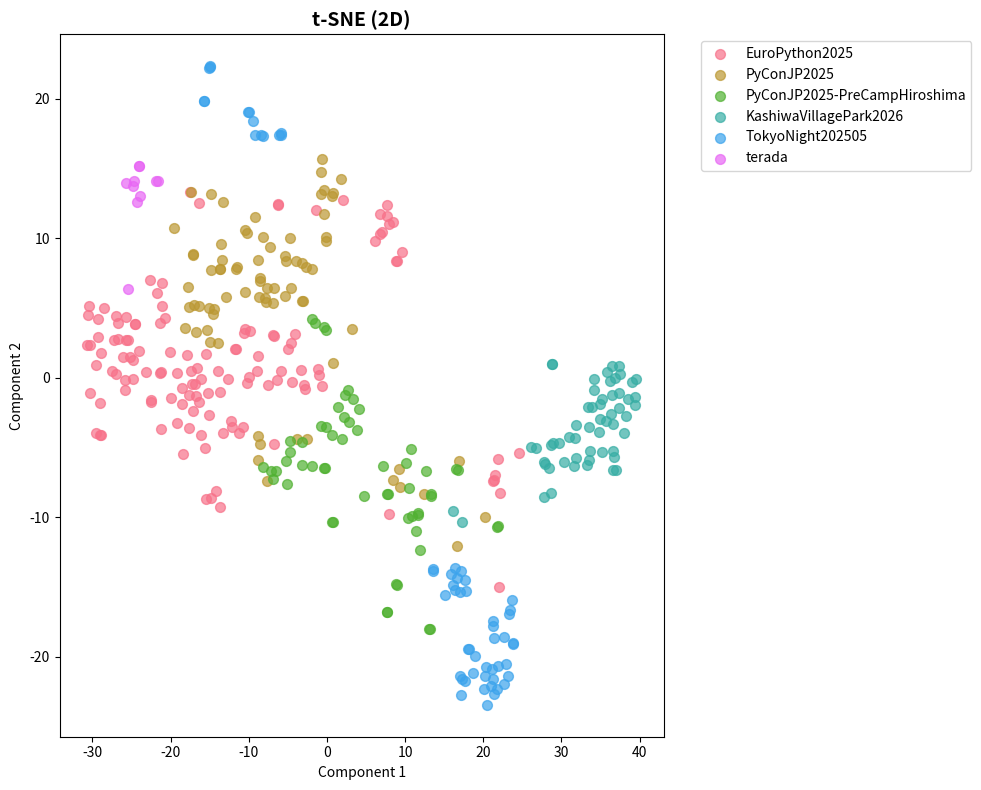

In [12]:
# t-SNE 2D 可視化
plot_2d_scatter(tsne_2d_coords, metadata["category"].tolist(), "t-SNE (2D)")
plt.tight_layout()
plt.show()

In [13]:
# t-SNE 3D
print("t-SNE (3D) を実行中...（時間がかかる場合があります）")
tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
tsne_3d_coords = tsne_3d.fit_transform(embeddings)
print("完了")

t-SNE (3D) を実行中...（時間がかかる場合があります）
完了


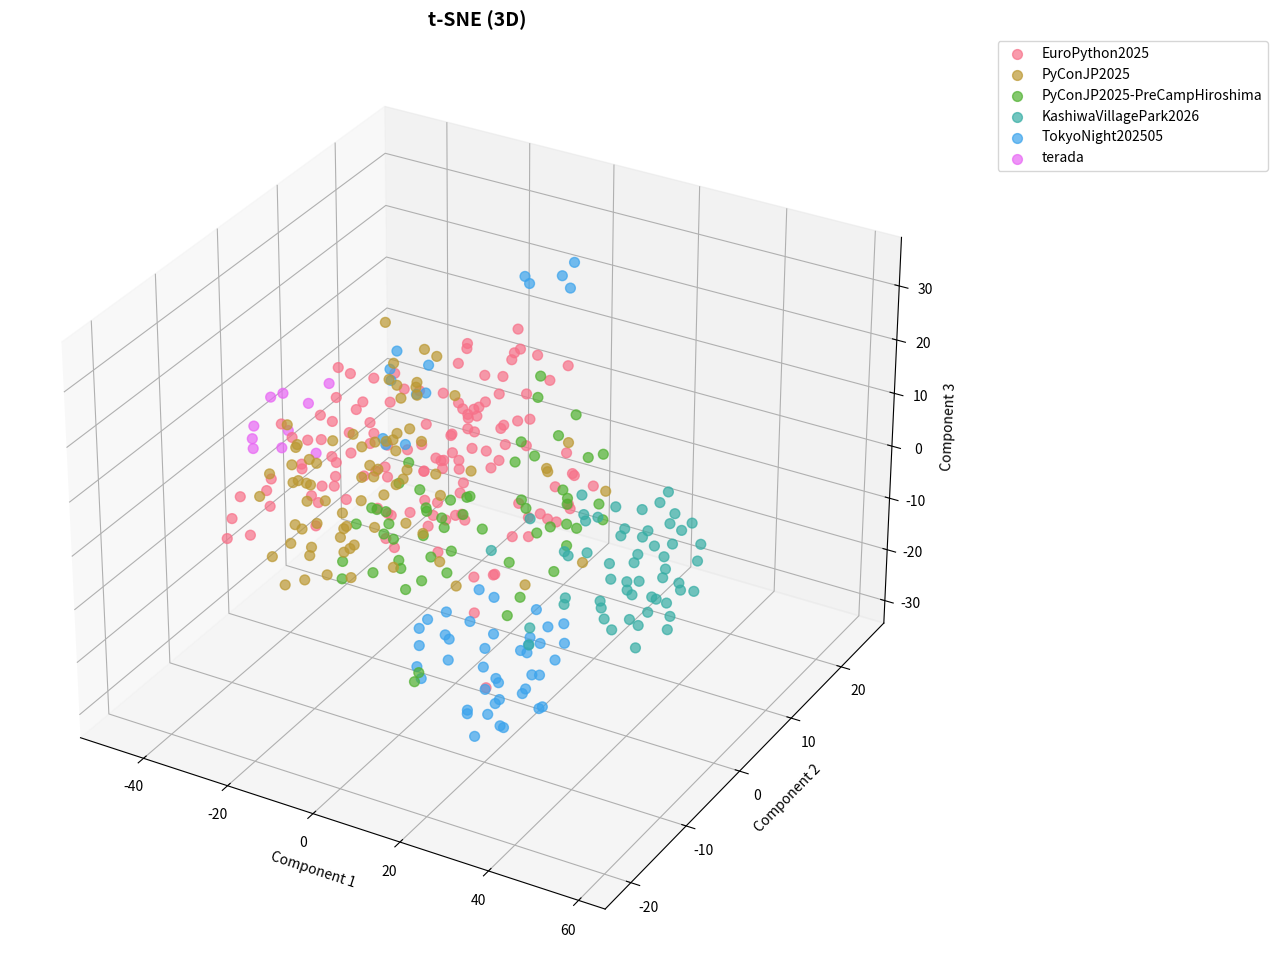

In [14]:
# t-SNE 3D 可視化
plot_3d_scatter(tsne_3d_coords, metadata["category"].tolist(), "t-SNE (3D)")
plt.tight_layout()
plt.show()

---
## 3. UMAP（オプショナル）

非線形次元削減手法。t-SNEより高速で、大域的な構造も保持する。

**注意**: umap-learnはPython 3.13との互換性問題があるため、インストールできない場合はこのセクションはスキップされます。

In [15]:
if UMAP_AVAILABLE:
    # UMAP 2D
    print("UMAP (2D) を実行中...")
    umap_2d = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_STATE,
    )
    umap_2d_coords = umap_2d.fit_transform(embeddings)
    print("完了")
else:
    print("UMAPは利用できません。スキップします。")
    umap_2d_coords = None

UMAPは利用できません。スキップします。


In [16]:
if umap_2d_coords is not None:
    # UMAP 2D 可視化
    plot_2d_scatter(umap_2d_coords, metadata["category"].tolist(), "UMAP (2D)")
    plt.tight_layout()
    plt.show()

In [17]:
if UMAP_AVAILABLE:
    # UMAP 3D
    print("UMAP (3D) を実行中...")
    umap_3d = umap.UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_STATE,
    )
    umap_3d_coords = umap_3d.fit_transform(embeddings)
    print("完了")
else:
    umap_3d_coords = None

In [18]:
if umap_3d_coords is not None:
    # UMAP 3D 可視化
    plot_3d_scatter(umap_3d_coords, metadata["category"].tolist(), "UMAP (3D)")
    plt.tight_layout()
    plt.show()

---
## 手法比較

3つの次元削減手法の2D結果を並べて比較する。

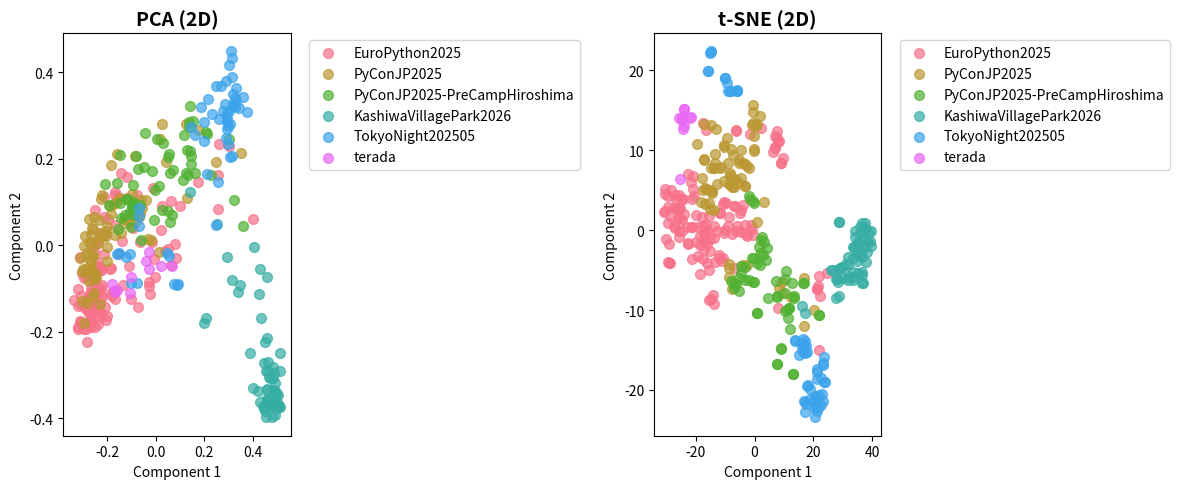

比較画像を data/comparison_2d.png に保存しました


In [19]:
# 利用可能な手法を収集
results_2d = {
    "PCA": pca_2d_coords,
    "t-SNE": tsne_2d_coords,
}
if umap_2d_coords is not None:
    results_2d["UMAP"] = umap_2d_coords

# 比較グリッド
n_methods = len(results_2d)
fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5))

if n_methods == 1:
    axes = [axes]

for ax, (method, coords) in zip(axes, results_2d.items()):
    plot_2d_scatter(coords, metadata["category"].tolist(), f"{method} (2D)", ax)

plt.tight_layout()
plt.savefig("../data/comparison_2d.png", dpi=150, bbox_inches="tight")
plt.show()

print("比較画像を data/comparison_2d.png に保存しました")

<cell_type>markdown</cell_type>---
## インタラクティブ可視化（Plotly + ipywidgets）

Plotlyを使って、マウス操作で自由に探索できるインタラクティブな可視化を行う。

- **点をクリックすると該当画像がポップアップ表示される**
- ホバーでファイル名・カテゴリを表示
- ドラッグで回転（3D）
- ホイールでズーム
- 凡例クリックでカテゴリの表示/非表示切替

In [20]:
def create_interactive_2d(
    coords: np.ndarray,
    df: pd.DataFrame,
    title: str,
) -> go.Figure:
    """インタラクティブ2D散布図を作成"""
    plot_df = df.copy()
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]
    
    fig = px.scatter(
        plot_df,
        x="x",
        y="y",
        color="category",
        hover_data=["file_name", "category"],
        title=title,
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(
        width=900,
        height=700,
        legend=dict(title="カテゴリ"),
    )
    
    return fig


def create_interactive_3d(
    coords: np.ndarray,
    df: pd.DataFrame,
    title: str,
) -> go.Figure:
    """インタラクティブ3D散布図を作成"""
    plot_df = df.copy()
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]
    plot_df["z"] = coords[:, 2]
    
    fig = px.scatter_3d(
        plot_df,
        x="x",
        y="y",
        z="z",
        color="category",
        hover_data=["file_name", "category"],
        title=title,
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    
    fig.update_traces(marker=dict(size=5, opacity=0.7))
    fig.update_layout(
        width=900,
        height=700,
        scene=dict(
            xaxis_title="Component 1",
            yaxis_title="Component 2",
            zaxis_title="Component 3",
        ),
    )
    
    return fig


def create_interactive_2d_with_image_popup(
    coords: np.ndarray,
    df: pd.DataFrame,
    title: str,
    base_path: Path = Path(".."),
) -> widgets.VBox:
    """クリックで画像をポップアップ表示するインタラクティブ2D散布図"""
    plot_df = df.copy()
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]
    
    # FigureWidgetを作成
    fig = go.FigureWidget()
    
    # カテゴリごとにトレースを追加
    colors = px.colors.qualitative.Set2
    categories = plot_df["category"].unique()
    
    for i, cat in enumerate(categories):
        mask = plot_df["category"] == cat
        cat_df = plot_df[mask]
        fig.add_trace(go.Scatter(
            x=cat_df["x"],
            y=cat_df["y"],
            mode="markers",
            name=cat,
            marker=dict(size=10, opacity=0.7, color=colors[i % len(colors)]),
            customdata=cat_df[["file_name", "category", "file_path"]].values,
            hovertemplate="<b>%{customdata[0]}</b><br>カテゴリ: %{customdata[1]}<extra></extra>",
        ))
    
    fig.update_layout(
        title=title,
        width=900,
        height=600,
        xaxis_title="Component 1",
        yaxis_title="Component 2",
        legend_title="カテゴリ",
    )
    
    # 画像表示用のOutput widget
    image_output = widgets.Output(layout=widgets.Layout(
        border="1px solid #ccc",
        padding="10px",
        margin="10px 0",
        min_height="200px",
    ))
    
    # 情報表示用のラベル
    info_label = widgets.HTML(value="<i>点をクリックすると画像が表示されます</i>")
    
    # クリックイベントハンドラ
    def on_click(trace, points, state):
        if points.point_inds:
            idx = points.point_inds[0]
            customdata = trace.customdata[idx]
            file_name = customdata[0]
            category = customdata[1]
            file_path = customdata[2]
            
            # 画像のフルパス
            image_path = base_path / file_path
            
            info_label.value = f"<b>{file_name}</b> (カテゴリ: {category})"
            
            with image_output:
                clear_output(wait=True)
                if image_path.exists():
                    display(IPImage(filename=str(image_path), width=400))
                else:
                    print(f"画像が見つかりません: {image_path}")
    
    # 各トレースにクリックイベントを設定
    for trace in fig.data:
        trace.on_click(on_click)
    
    return widgets.VBox([fig, info_label, image_output])


def create_interactive_3d_with_image_popup(
    coords: np.ndarray,
    df: pd.DataFrame,
    title: str,
    base_path: Path = Path(".."),
) -> widgets.VBox:
    """クリックで画像をポップアップ表示するインタラクティブ3D散布図"""
    plot_df = df.copy()
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]
    plot_df["z"] = coords[:, 2]
    
    # FigureWidgetを作成
    fig = go.FigureWidget()
    
    # カテゴリごとにトレースを追加
    colors = px.colors.qualitative.Set2
    categories = plot_df["category"].unique()
    
    for i, cat in enumerate(categories):
        mask = plot_df["category"] == cat
        cat_df = plot_df[mask]
        fig.add_trace(go.Scatter3d(
            x=cat_df["x"],
            y=cat_df["y"],
            z=cat_df["z"],
            mode="markers",
            name=cat,
            marker=dict(size=5, opacity=0.7, color=colors[i % len(colors)]),
            customdata=cat_df[["file_name", "category", "file_path"]].values,
            hovertemplate="<b>%{customdata[0]}</b><br>カテゴリ: %{customdata[1]}<extra></extra>",
        ))
    
    fig.update_layout(
        title=title,
        width=900,
        height=600,
        scene=dict(
            xaxis_title="Component 1",
            yaxis_title="Component 2",
            zaxis_title="Component 3",
        ),
        legend_title="カテゴリ",
    )
    
    # 画像表示用のOutput widget
    image_output = widgets.Output(layout=widgets.Layout(
        border="1px solid #ccc",
        padding="10px",
        margin="10px 0",
        min_height="200px",
    ))
    
    # 情報表示用のラベル
    info_label = widgets.HTML(value="<i>点をクリックすると画像が表示されます</i>")
    
    # クリックイベントハンドラ
    def on_click(trace, points, state):
        if points.point_inds:
            idx = points.point_inds[0]
            customdata = trace.customdata[idx]
            file_name = customdata[0]
            category = customdata[1]
            file_path = customdata[2]
            
            # 画像のフルパス
            image_path = base_path / file_path
            
            info_label.value = f"<b>{file_name}</b> (カテゴリ: {category})"
            
            with image_output:
                clear_output(wait=True)
                if image_path.exists():
                    display(IPImage(filename=str(image_path), width=400))
                else:
                    print(f"画像が見つかりません: {image_path}")
    
    # 各トレースにクリックイベントを設定
    for trace in fig.data:
        trace.on_click(on_click)
    
    return widgets.VBox([fig, info_label, image_output])

In [21]:
# インタラクティブ2D（t-SNE結果を使用）- クリックで画像表示
widget_2d = create_interactive_2d_with_image_popup(
    tsne_2d_coords, metadata, "t-SNE (2D) - クリックで画像表示"
)
display(widget_2d)

    'data': [{'customdata': array([['2025-07-16 00.24.07.jpg', 'EuroPython2025',…

In [22]:
# インタラクティブ3D（t-SNE結果を使用）- クリックで画像表示
widget_3d = create_interactive_3d_with_image_popup(
    tsne_3d_coords, metadata, "t-SNE (3D) - クリックで画像表示"
)
display(widget_3d)

    'data': [{'customdata': array([['2025-07-16 00.24.07.jpg', 'EuroPython2025',…

In [23]:
# UMAPが利用可能な場合は追加で表示
if umap_2d_coords is not None:
    widget_umap_2d = create_interactive_2d_with_image_popup(
        umap_2d_coords, metadata, "UMAP (2D) - クリックで画像表示"
    )
    display(widget_umap_2d)

In [24]:
if umap_3d_coords is not None:
    widget_umap_3d = create_interactive_3d_with_image_popup(
        umap_3d_coords, metadata, "UMAP (3D) - クリックで画像表示"
    )
    display(widget_umap_3d)

---
## 考察

各次元削減手法の結果を比較し、以下の観点で考察する：

1. **カテゴリの分離度**: 同じカテゴリの画像がまとまっているか
2. **クラスタの形成**: 明確なクラスタが形成されているか
3. **外れ値**: 他のカテゴリと混在している画像はあるか

### 手法の特徴

| 手法 | 特徴 | 適用場面 |
|------|------|----------|
| PCA | 線形、高速、解釈しやすい | 全体構造の把握、前処理 |
| t-SNE | 非線形、クラスタ分離に強い | 局所的なパターン発見 |
| UMAP | 非線形、高速、大域構造も保持 | バランスの取れた可視化 |

---
## 定量的評価

次元削減の品質を以下の指標で評価する：

1. **シルエットスコア** (-1〜1): クラスタの分離度。1に近いほど良い分離
2. **Trustworthiness** (0〜1): 低次元空間での近傍関係の信頼性。1に近いほど元の構造を保持
3. **カテゴリ内/カテゴリ間距離比**: 同カテゴリ内の平均距離 / 異カテゴリ間の平均距離。小さいほど良い分離

In [25]:
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness
from scipy.spatial.distance import pdist, squareform


def compute_intra_inter_ratio(coords: np.ndarray, labels: np.ndarray) -> float:
    """カテゴリ内距離とカテゴリ間距離の比を計算"""
    dist_matrix = squareform(pdist(coords))
    
    intra_distances = []
    inter_distances = []
    
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if labels[i] == labels[j]:
                intra_distances.append(dist_matrix[i, j])
            else:
                inter_distances.append(dist_matrix[i, j])
    
    if len(intra_distances) == 0 or len(inter_distances) == 0:
        return np.nan
    
    return np.mean(intra_distances) / np.mean(inter_distances)


def evaluate_reduction(
    name: str,
    coords_2d: np.ndarray,
    coords_3d: np.ndarray | None,
    original: np.ndarray,
    labels: np.ndarray,
) -> dict:
    """次元削減結果を評価"""
    results = {"手法": name}
    
    # 2D評価
    results["シルエット(2D)"] = silhouette_score(coords_2d, labels)
    results["Trustworthiness(2D)"] = trustworthiness(original, coords_2d, n_neighbors=10)
    results["距離比(2D)"] = compute_intra_inter_ratio(coords_2d, labels)
    
    # 3D評価
    if coords_3d is not None:
        results["シルエット(3D)"] = silhouette_score(coords_3d, labels)
        results["Trustworthiness(3D)"] = trustworthiness(original, coords_3d, n_neighbors=10)
        results["距離比(3D)"] = compute_intra_inter_ratio(coords_3d, labels)
    
    return results

In [26]:
# 各手法の評価
labels = metadata["category"].values

eval_results = []

# PCA
eval_results.append(evaluate_reduction(
    "PCA", pca_2d_coords, pca_3d_coords, embeddings, labels
))

# t-SNE
eval_results.append(evaluate_reduction(
    "t-SNE", tsne_2d_coords, tsne_3d_coords, embeddings, labels
))

# UMAP（利用可能な場合）
if umap_2d_coords is not None:
    eval_results.append(evaluate_reduction(
        "UMAP", umap_2d_coords, umap_3d_coords, embeddings, labels
    ))

# 結果をDataFrameで表示
eval_df = pd.DataFrame(eval_results)
eval_df = eval_df.set_index("手法")

# 数値を見やすくフォーマット
styled_df = eval_df.style.format("{:.4f}").background_gradient(
    cmap="RdYlGn",
    subset=["シルエット(2D)", "シルエット(3D)", "Trustworthiness(2D)", "Trustworthiness(3D)"],
    vmin=-1, vmax=1
).background_gradient(
    cmap="RdYlGn_r",  # 距離比は小さいほど良いので逆
    subset=["距離比(2D)", "距離比(3D)"],
)

display(styled_df)

,シルエット(2D),Trustworthiness(2D),距離比(2D),シルエット(3D),Trustworthiness(3D),距離比(3D)
手法,,,,,,
PCA,0.0979,0.8342,0.4544,0.1033,0.8644,0.5158
t-SNE,0.1258,0.9560,0.5082,0.0981,0.9579,0.6087


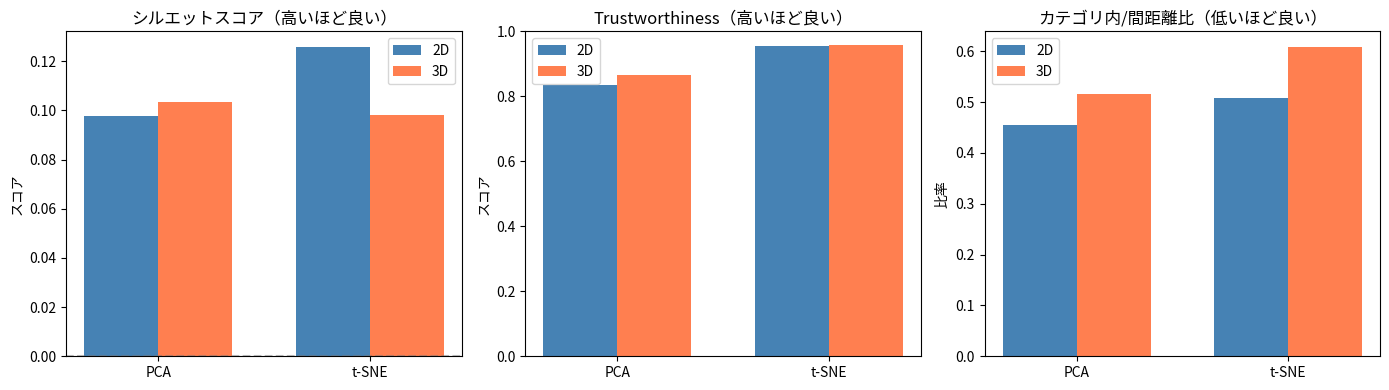

評価結果を data/evaluation_metrics.png に保存しました


In [27]:
# 評価指標の可視化
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

methods = eval_df.index.tolist()
x = np.arange(len(methods))
width = 0.35

# シルエットスコア
ax = axes[0]
ax.bar(x - width/2, eval_df["シルエット(2D)"], width, label="2D", color="steelblue")
ax.bar(x + width/2, eval_df["シルエット(3D)"], width, label="3D", color="coral")
ax.set_ylabel("スコア")
ax.set_title("シルエットスコア（高いほど良い）")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# Trustworthiness
ax = axes[1]
ax.bar(x - width/2, eval_df["Trustworthiness(2D)"], width, label="2D", color="steelblue")
ax.bar(x + width/2, eval_df["Trustworthiness(3D)"], width, label="3D", color="coral")
ax.set_ylabel("スコア")
ax.set_title("Trustworthiness（高いほど良い）")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0, 1)

# 距離比
ax = axes[2]
ax.bar(x - width/2, eval_df["距離比(2D)"], width, label="2D", color="steelblue")
ax.bar(x + width/2, eval_df["距離比(3D)"], width, label="3D", color="coral")
ax.set_ylabel("比率")
ax.set_title("カテゴリ内/間距離比（低いほど良い）")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

plt.tight_layout()
plt.savefig("../data/evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("評価結果を data/evaluation_metrics.png に保存しました")

In [28]:
# 評価サマリーの出力
print("=" * 60)
print("評価サマリー")
print("=" * 60)

# 各指標でベストな手法を特定
best_silhouette_2d = eval_df["シルエット(2D)"].idxmax()
best_silhouette_3d = eval_df["シルエット(3D)"].idxmax()
best_trust_2d = eval_df["Trustworthiness(2D)"].idxmax()
best_trust_3d = eval_df["Trustworthiness(3D)"].idxmax()
best_ratio_2d = eval_df["距離比(2D)"].idxmin()
best_ratio_3d = eval_df["距離比(3D)"].idxmin()

print(f"\n【2D次元削減】")
print(f"  シルエットスコア最良: {best_silhouette_2d} ({eval_df.loc[best_silhouette_2d, 'シルエット(2D)']:.4f})")
print(f"  Trustworthiness最良: {best_trust_2d} ({eval_df.loc[best_trust_2d, 'Trustworthiness(2D)']:.4f})")
print(f"  距離比最良: {best_ratio_2d} ({eval_df.loc[best_ratio_2d, '距離比(2D)']:.4f})")

print(f"\n【3D次元削減】")
print(f"  シルエットスコア最良: {best_silhouette_3d} ({eval_df.loc[best_silhouette_3d, 'シルエット(3D)']:.4f})")
print(f"  Trustworthiness最良: {best_trust_3d} ({eval_df.loc[best_trust_3d, 'Trustworthiness(3D)']:.4f})")
print(f"  距離比最良: {best_ratio_3d} ({eval_df.loc[best_ratio_3d, '距離比(3D)']:.4f})")

print("\n" + "=" * 60)
print("指標の解釈")
print("=" * 60)
print("""
- シルエットスコア: カテゴリ間の分離度を測定。
  0.5以上で良好、0.7以上で優秀。負の値はクラスタが混在。

- Trustworthiness: 元の高次元空間の近傍関係が保持されているか。
  0.9以上が望ましい。低い値は局所構造が歪んでいる可能性。

- 距離比: 同カテゴリ内と異カテゴリ間の距離の比。
  1未満で良好（同カテゴリがより近い）。値が小さいほど分離が良い。
""")

評価サマリー

【2D次元削減】
  シルエットスコア最良: t-SNE (0.1258)
  Trustworthiness最良: t-SNE (0.9560)
  距離比最良: PCA (0.4544)

【3D次元削減】
  シルエットスコア最良: PCA (0.1033)
  Trustworthiness最良: t-SNE (0.9579)
  距離比最良: PCA (0.5158)

指標の解釈

- シルエットスコア: カテゴリ間の分離度を測定。
  0.5以上で良好、0.7以上で優秀。負の値はクラスタが混在。

- Trustworthiness: 元の高次元空間の近傍関係が保持されているか。
  0.9以上が望ましい。低い値は局所構造が歪んでいる可能性。

- 距離比: 同カテゴリ内と異カテゴリ間の距離の比。
  1未満で良好（同カテゴリがより近い）。値が小さいほど分離が良い。



In [29]:
# 接続を閉じる
conn.close()
print("完了")

完了
